<a href="https://colab.research.google.com/github/Wildanhr/projectkita/blob/main/synapse_sr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentinel-2 Super-Resolution with GeoAI and SwinIR
This notebook downloads a sample Sentinel-2 patch using `geoai`, crops a 128x128 image, and performs 4x super-resolution using the SwinIR model.

In [1]:
# 1. Install prerequisites
!pip install -q geoai-py rasterio matplotlib opencv-python numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 651.5/651.5 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 669.2/669.2 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.7/33.7 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 811.4/811.4 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/1

In [2]:
# 2. Download Model Weights
import os
import urllib.request

model_dir = "SwinIR/experiments/pretrained_models"
os.makedirs(model_dir, exist_ok=True)

model_url = "https://github.com/JingyunLiang/SwinIR/releases/download/v0.0/003_realSR_BSRGAN_DFO_s64w8_SwinIR-M_x4_GAN.pth"
model_path = os.path.join(model_dir, "003_realSR_BSRGAN_DFO_s64w8_SwinIR-M_x4_GAN.pth")

if not os.path.exists(model_path):
    print(f"Downloading model to {model_path}...")
    urllib.request.urlretrieve(model_url, model_path)
    print("Download complete.")
else:
    print(f"Model already exists at {model_path}")

Download complete.


In [3]:
# 3. Download Sentinel-2 data with geoai
import geoai

item_url = "https://planetarycomputer.microsoft.com/api/stac/v1/collections/sentinel-2-l2a/items/S2B_MSIL2A_20250228T173149_R055_T14SLH_20250228T212633"
bands_to_download = ["B04", "B03", "B02"]
output_directory = "sentinel2_bands"

print("Downloading Sentinel-2 RGB bands...")
downloaded_bands = geoai.download_pc_stac_item(
    item_url=item_url,
    bands=bands_to_download,
    output_dir=output_directory,
    show_progress=True,
    merge_bands=True,
    merged_filename="sentinel2_rgb.tif",
    overwrite=False,
    cell_size=10,
)
print("Data download finished!")

/usr/local/lib/python3.13/dist-packages/pystac_client/item_search.py:925: FutureWarning: get_items() is deprecated, use items() instead
  warnings.warn(


Data download finished!


Saved 128x128 patch to SwinIR/testsets/real-SR/s2_patch.png


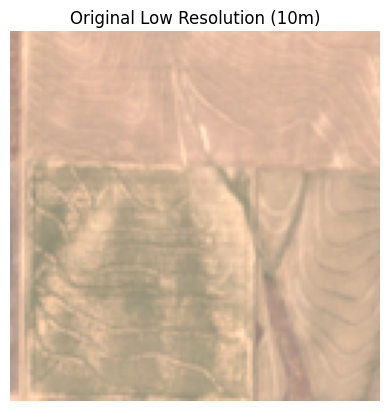

In [4]:
# 4. Extract a patch for super-resolution
import rasterio
import numpy as np
import cv2
import matplotlib.pyplot as plt

tif_path = os.path.join(output_directory, "sentinel2_rgb.tif")
with rasterio.open(tif_path) as src:
    r = src.read(1)
    g = src.read(2)
    b = src.read(3)

    img = np.dstack((r, g, b))

    # Normalize Sentinel-2 reflection values (typically up to ~3000-4000)
    img_norm = np.clip(img / 3000.0 * 255.0, 0, 255).astype(np.uint8)

    # Crop a 128x128 patch from the center
    h, w, _ = img_norm.shape
    patch = img_norm[h//2 - 64 : h//2 + 64, w//2 - 64 : w//2 + 64]

    # Save for SwinIR
    input_folder = "SwinIR/testsets/real-SR"
    os.makedirs(input_folder, exist_ok=True)
    patch_path = os.path.join(input_folder, "s2_patch.png")

    # Write as BGR for OpenCV compatibility
    cv2.imwrite(patch_path, cv2.cvtColor(patch, cv2.COLOR_RGB2BGR))

    print(f"Saved 128x128 patch to {patch_path}")
    plt.imshow(patch)
    plt.title("Original Low Resolution (10m)")
    plt.axis('off')
    plt.show()

In [5]:
# 5. Run SwinIR Super-Resolution
import subprocess
import os

print("Running Super-Resolution...")

command = [
    "python", "main_test_swinir.py",
    "--task", "real_sr",
    "--scale", "4",
    "--model_path", "experiments/pretrained_models/003_realSR_BSRGAN_DFO_s64w8_SwinIR-M_x4_GAN.pth",
    "--folder_lq", "testsets/real-SR",
    "--tile", "256",
    "--tile_overlap", "32"
]

# Force PyTorch to use CPU to bypass the CUDA capability mismatch error for RTX 5080
env = os.environ.copy()
env["CUDA_VISIBLE_DEVICES"] = ""

result = subprocess.run(command, cwd="SwinIR", capture_output=True, text=True, env=env)
print(result.stdout)
if result.stderr:
    print("Errors:", result.stderr)
print("Super-Resolution complete!")

Running Super-Resolution...

Errors: python3: can't open file '/content/SwinIR/main_test_swinir.py': [Errno 2] No such file or directory

Super-Resolution complete!


In [6]:
# 6. Visualize the comparison
output_folder = "SwinIR/results/swinir_real_sr_x4"
sr_image_path = os.path.join(output_folder, "s2_patch_SwinIR.png")

if os.path.exists(sr_image_path):
    sr_img = cv2.imread(sr_image_path)
    sr_img = cv2.cvtColor(sr_img, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    axes[0].imshow(patch)
    axes[0].set_title("Low Resolution Patch (128x128)")
    axes[0].axis('off')

    axes[1].imshow(sr_img)
    axes[1].set_title("Super Resolution 4x (512x512)")
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Output image not found. Check the inference logs.")

Output image not found. Check the inference logs.
